In [18]:
!pip install streamlit -q
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer(as_frame=True)
df = data.frame

In [19]:
print(df.shape)
df.head()

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [20]:
df['target'].value_counts()

,count
target,
1,357
0,212


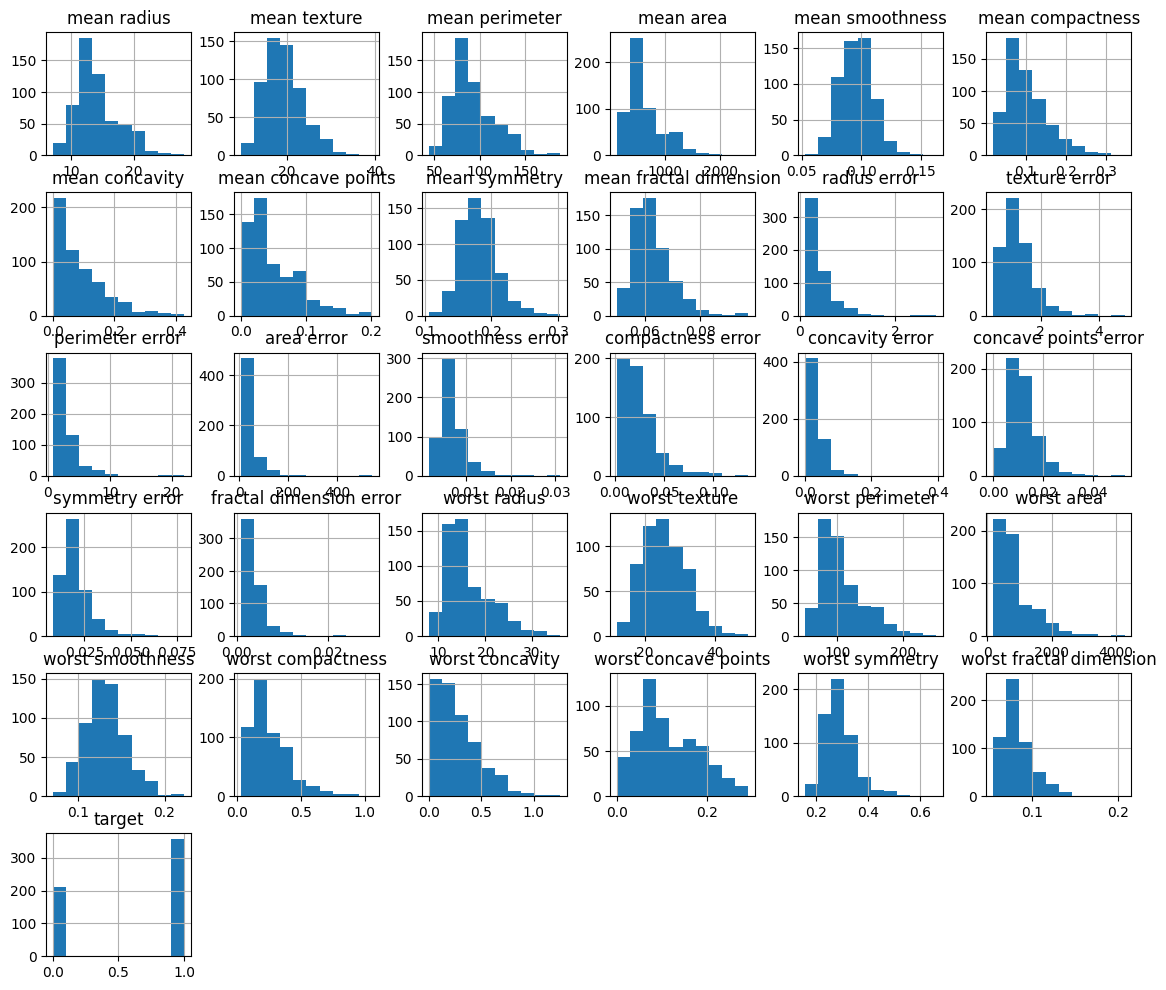

In [21]:
import matplotlib.pyplot as plt
df.hist(figsize=(14, 12))
plt.show()

In [22]:
print(df.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


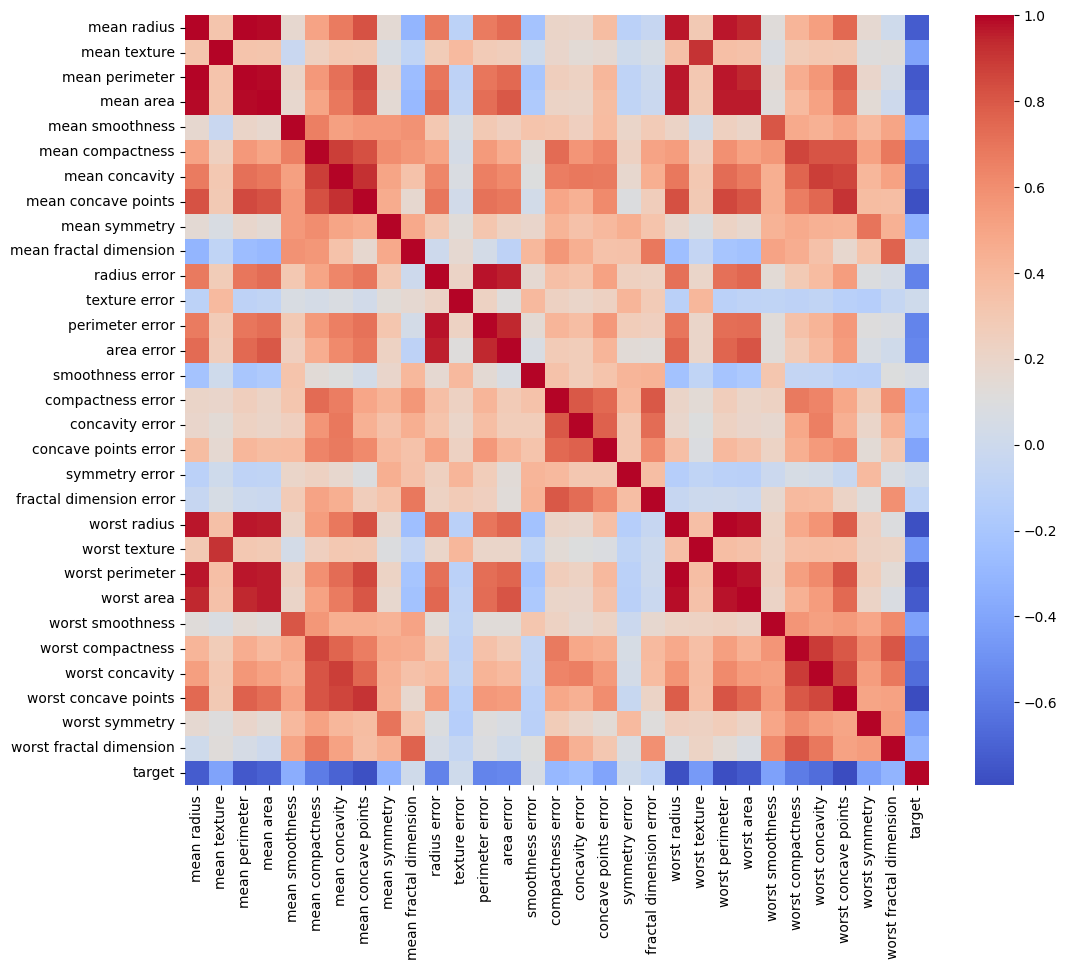

In [23]:
import seaborn as sns
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [24]:
df.corr()['target'].abs().sort_values(ascending=False).head(10)

,target
target,1.000000
worst concave points,0.793566
worst perimeter,0.782914
mean concave points,0.776614
worst radius,0.776454
mean perimeter,0.742636
worst area,0.733825
mean radius,0.730029
mean area,0.708984
mean concavity,0.696360


In [27]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['target'])   # the measurements
y = df['target']                  # the answers

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [28]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train_s, y_train)

RandomForestClassifier(random_state=42)

In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
preds = model.predict(X_test_s)
print(accuracy_score(y_test, preds))
print(classification_report(y_test, preds))
print(confusion_matrix(y_test, preds))

0.956140350877193
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

[[39  3]
 [ 2 70]]


In [30]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_s, y_train)
lr_preds = lr.predict(X_test_s)
print(accuracy_score(y_test, lr_preds))
print(classification_report(y_test, lr_preds))

0.9824561403508771
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [31]:
import joblib
joblib.dump(lr, 'model.joblib')
joblib.dump(scaler, 'scaler.joblib')

['scaler.joblib']

In [32]:
%%writefile app.py
import streamlit as st
import joblib
import numpy as np
from sklearn.datasets import load_breast_cancer

model = joblib.load('model.joblib')
scaler = joblib.load('scaler.joblib')
data = load_breast_cancer(as_frame=True)
X = data.frame.drop(columns=['target'])

st.title('Breast Cancer Diagnosis Predictor')
st.write('Enter tumor measurements to predict malignant vs. benign.')

values = []
for col in X.columns:
    values.append(st.number_input(col, value=float(X[col].mean())))

if st.button('Predict'):
    scaled = scaler.transform(np.array([values]))
    pred = model.predict(scaled)[0]
    if pred == 1:
        st.success('Prediction: Benign')
    else:
        st.error('Prediction: Malignant')
    st.caption('Educational project only, not a medical diagnosis.')

Writing app.py


In [33]:
import sklearn
print(sklearn.__version__)

1.6.1


In [35]:
%%writefile requirements.txt
streamlit
scikit-learn==1.6.1
joblib
numpy
pandas

Overwriting requirements.txt
